In [ ]:
# ==============================
# STUDENT SCORE PREDICTION
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df = pd.read_csv("score_updated.csv")

print(df.head())
print(df.info())



   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   96 non-null     float64
 1   Scores  96 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.6 KB
None


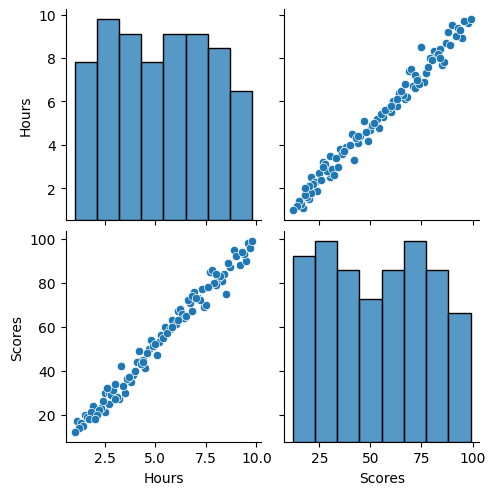

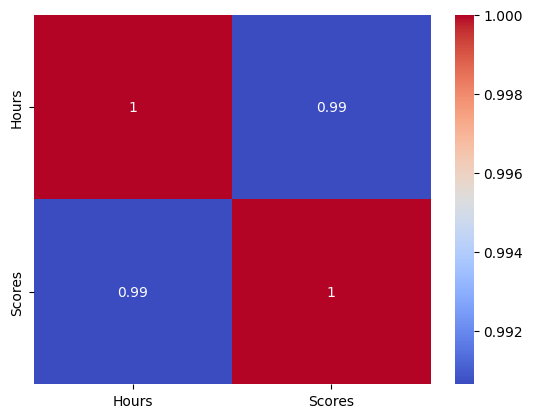

In [ ]:
# ==============================
# EDA
# ==============================

sns.pairplot(df)
plt.show()

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


In [ ]:

# ==============================
# Model Building
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

X = df.drop(columns=['Scores'])   # change if column name differs
y = df['Scores']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Models
lr = LinearRegression()
dt = DecisionTreeRegressor()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
pred_dt = dt.predict(X_test)

print(pred_lr)
print(pred_dt)

[28.01321679 50.63517747 31.94747083 38.83241538 82.10920972 87.02702726
 76.20782868 68.33932061 27.02965329 78.17495569 55.55299501 18.17758172
 62.43793957 36.86528836 90.96128129 95.87909883 46.70092344 39.81597889
 37.84885187 51.61874098]
[30.  54.  34.  37.  83.  87.  69.  72.  30.  78.  56.  20.  63.  33.
 95.  93.  44.5 37.  37.  47. ]


In [ ]:
# ==============================
# Evaluation
# ==============================

from sklearn.metrics import r2_score

print("Linear Regression R2:", r2_score(y_test, pred_lr))
print("Decision Tree R2:", r2_score(y_test, pred_dt))

Linear Regression R2: 0.9708871356050831
Decision Tree R2: 0.9755002653246375


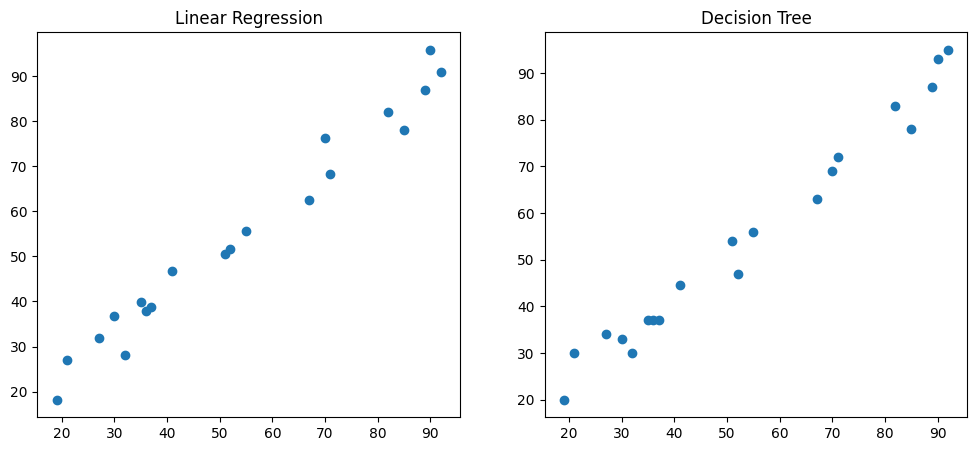

In [ ]:
# ==============================
# Dashboard
# ==============================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test, pred_lr)
plt.title("Linear Regression")

plt.subplot(1,2,2)
plt.scatter(y_test, pred_dt)
plt.title("Decision Tree")

plt.show()